In [22]:
!pip install pytesseract opencv-python numpy matplotlib

In [23]:
!sudo apt install tesseract-ocr

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
tesseract-ocr is already the newest version (4.1.1-2.1build1).
0 upgraded, 0 newly installed, 0 to remove and 38 not upgraded.


In [24]:
!pip install easyocr


Mounted at /content/drive
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
tesseract-ocr is already the newest version (4.1.1-2.1build1).
0 upgraded, 0 newly installed, 0 to remove and 38 not upgraded.

Extracted Sudoku:
[[7 0 0 8 0 3 0 0 5]
 [0 0 5 0 7 0 3 0 0]
 [0 4 0 0 6 0 0 2 0]
 [5 0 0 0 0 0 0 0 1]
 [0 6 4 0 0 0 2 9 0]
 [2 0 0 0 0 0 0 0 6]
 [0 7 0 0 2 0 0 8 0]
 [0 0 8 0 3 0 6 0 0]
 [6 0 0 4 0 9 0 0 7]]


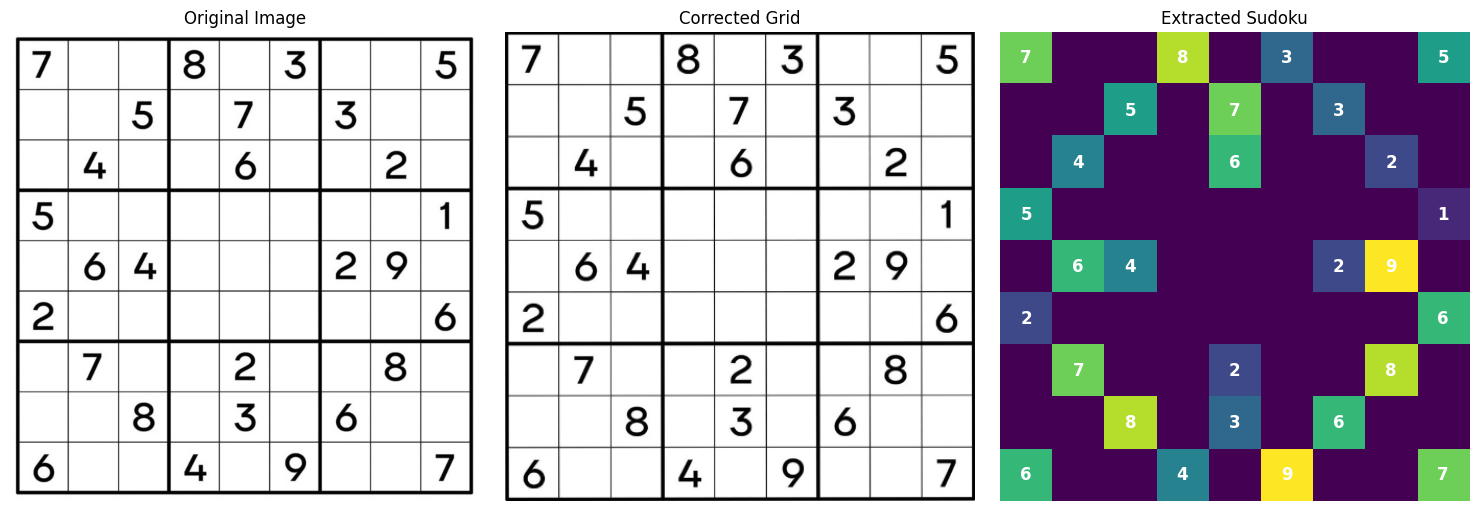


Readable Sudoku:
7 . . | 8 . 3 | . . 5 
. . 5 | . 7 . | 3 . . 
. 4 . | . 6 . | . 2 . 
---------------------
5 . . | . . . | . . 1 
. 6 4 | . . . | 2 9 . 
2 . . | . . . | . . 6 
---------------------
. 7 . | . 2 . | . 8 . 
. . 8 | . 3 . | 6 . . 
6 . . | 4 . 9 | . . 7 


In [28]:
# ==============================================================================
# 1. SETUP AND INSTALLATION
# ==============================================================================

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

# Install dependencies
!pip install opencv-python numpy matplotlib pytesseract
!sudo apt install tesseract-ocr

# Import libraries
import cv2
import numpy as np
import pytesseract
from matplotlib import pyplot as plt

# ==============================================================================
# 2. IMAGE LOADING AND PREPROCESSING
# ==============================================================================

# !!! ADJUST THIS PATH TO YOUR IMAGE !!!
image_path = '/content/drive/MyDrive/SI/imagenes/sudoku2.jpg'

# Load the image
image = cv2.imread(image_path)
if image is None:
    raise Exception("Error: Could not load image from path: {image_path}")

# Resize if too large
height, width = image.shape[:2]
if width > 800:
    scale = 800 / width
    image = cv2.resize(image, (int(width * scale), int(height * scale)))

gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Enhanced preprocessing
blurred_image = cv2.GaussianBlur(gray_image, (5, 5), 0)
threshold_image = cv2.adaptiveThreshold(
    blurred_image, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY_INV, 11, 2
)

# ==============================================================================
# 3. MAIN GRID DETECTION
# ==============================================================================

# Find the largest contour (the outer grid)
external_contours, _ = cv2.findContours(threshold_image.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

if not external_contours:
    raise Exception("Error: No external contours found.")

grid_contour = max(external_contours, key=cv2.contourArea)

# Approximate contour to polygon
epsilon = 0.02 * cv2.arcLength(grid_contour, True)
approx_corners = cv2.approxPolyDP(grid_contour, epsilon, True)

# If 4 points detected, apply perspective transform
if len(approx_corners) == 4:
    points = approx_corners.reshape(4, 2).astype(np.float32)

    # Order points: top-left, top-right, bottom-right, bottom-left
    ordered_points = np.zeros((4, 2), dtype=np.float32)
    s = points.sum(axis=1)
    ordered_points[0] = points[np.argmin(s)]  # top-left
    ordered_points[2] = points[np.argmax(s)]  # bottom-right

    diff = np.diff(points, axis=1)
    ordered_points[1] = points[np.argmin(diff)]  # top-right
    ordered_points[3] = points[np.argmax(diff)]  # bottom-left

    # Output size
    side_length = 450
    destination_points = np.array([
        [0, 0],
        [side_length - 1, 0],
        [side_length - 1, side_length - 1],
        [0, side_length - 1]
    ], dtype=np.float32)

    # Apply perspective transform
    transform_matrix = cv2.getPerspectiveTransform(ordered_points, destination_points)
    warped_gray = cv2.warpPerspective(gray_image, transform_matrix, (side_length, side_length))
    warped_thresh = cv2.warpPerspective(threshold_image, transform_matrix, (side_length, side_length))
else:
    # If 4 corners not detected, crop bounding rectangle
    x_grid, y_grid, w_grid, h_grid = cv2.boundingRect(grid_contour)
    warped_gray = gray_image[y_grid:y_grid+h_grid, x_grid:x_grid+w_grid]
    warped_thresh = threshold_image[y_grid:y_grid+h_grid, x_grid:x_grid+w_grid]
    side_length = max(warped_gray.shape)
    warped_gray = cv2.resize(warped_gray, (side_length, side_length))
    warped_thresh = cv2.resize(warped_thresh, (side_length, side_length))

# ==============================================================================
# 4. DIRECT CELL EXTRACTION
# ==============================================================================

def extract_sudoku_grid(warped_gray_img, warped_thresh_img):
    """
    Extracts sudoku by dividing the image directly into 9x9 cells
    """
    sudoku_matrix = np.zeros((9, 9), dtype=int)
    cell_size = warped_gray_img.shape[0] // 9

    # Kernel for digit dilation
    kernel = np.ones((2, 2), np.uint8)

    for row in range(9):
        for col in range(9):
            # Extract cell with margins
            y1 = row * cell_size
            y2 = (row + 1) * cell_size
            x1 = col * cell_size
            x2 = (col + 1) * cell_size

            cell = warped_thresh_img[y1:y2, x1:x2]

            # Apply inner margins to avoid grid lines
            margin = int(cell_size * 0.15)
            cell = cell[margin:-margin, margin:-margin]

            if cell.size == 0:
                continue

            # Check if cell has significant content
            white_pixels = cv2.countNonZero(cell)
            total_pixels = cell.shape[0] * cell.shape[1]

            if white_pixels < total_pixels * 0.05:
                sudoku_matrix[row, col] = 0
                continue

            # Preprocess for OCR
            resized_cell = cv2.resize(cell, (64, 64), interpolation=cv2.INTER_AREA)

            # Dilate digits
            resized_cell = cv2.dilate(resized_cell, kernel, iterations=1)

            # Add black border
            bordered_cell = cv2.copyMakeBorder(
                resized_cell, 10, 10, 10, 10,
                cv2.BORDER_CONSTANT, value=[0, 0, 0]
            )

            # Invert for Tesseract (expects black text on white)
            ocr_ready_cell = cv2.bitwise_not(bordered_cell)

            # Tesseract configuration
            ocr_config = r'--oem 3 --psm 10 -c tessedit_char_whitelist=123456789'

            try:
                digit = pytesseract.image_to_string(ocr_ready_cell, config=ocr_config).strip()

                if digit.isdigit() and len(digit) == 1:
                    sudoku_matrix[row, col] = int(digit)
                else:
                    sudoku_matrix[row, col] = 0
            except:
                sudoku_matrix[row, col] = 0

    return sudoku_matrix

# ==============================================================================
# 5. EXECUTION AND VISUALIZATION
# ==============================================================================

# Extract sudoku
sudoku = extract_sudoku_grid(warped_gray, warped_thresh)

# Print result
print("\nExtracted Sudoku:")
print(sudoku)

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Original image
axes[0].imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
axes[0].set_title('Original Image')
axes[0].axis('off')

# Warped grid
axes[1].imshow(warped_gray, cmap='gray')
axes[1].set_title('Corrected Grid')
axes[1].axis('off')

# Extracted sudoku
axes[2].imshow(sudoku, cmap='viridis')
axes[2].set_title('Extracted Sudoku')
for row in range(9):
    for col in range(9):
        if sudoku[row, col] != 0:
            axes[2].text(col, row, sudoku[row, col], ha='center', va='center',
                        color='white', fontsize=12, weight='bold')
axes[2].axis('off')

plt.tight_layout()
plt.show()

# Pretty print
print("\nReadable Sudoku:")
for row in range(9):
    if row % 3 == 0 and row != 0:
        print("-" * 21)
    row_str = ""
    for col in range(9):
        if col % 3 == 0 and col != 0:
            row_str += "| "
        row_str += str(sudoku[row, col]) if sudoku[row, col] != 0 else "."
        row_str += " "
    print(row_str)


### 🧾 Memoria explicativa del proyecto: Reconocimiento de un Sudoku con OCR

En este proyecto, he creado un sistema sencillo que tiene la capacidad de **identificar de manera automática un tablero de Sudoku a partir de una imagen** y **distinguir los números que presenta**.  
Para eso, empleé el motor de **reconocimiento óptico de caracteres (OCR)** *Tesseract* y métodos básicos de **visión por computadora** con *OpenCV*.

---

#### 1. Instalación y configuración
Las librerías `numpy`, `opencv-python`, `pytesseract` y `matplotlib` son las primeras que se instalan.  
Además, para que el OCR opere de manera adecuada, se instala *tesseract-ocr* desde el sistema.  

También, se instala Google Drive para tener un acceso sencillo a las imágenes de entrada.

---

#### 2. Carga y preprocesamiento de la imagen
La imagen del Sudoku se convierte a escala de grises después de ser cargada.  
Después, utilizo un umbral adaptativo para enfatizar los números y las líneas de la tabla y uno gaussiano para disminuir el ruido.  

El resultado es una imagen binaria que simplifica la detección de los contornos.

---

#### 3. Detección de la cuadrícula principal
Se escoge el contorno de mayor tamaño, que es el que corresponde a los bordes del Sudoku.  
Se hace un **cálculo de transformación de perspectiva** a partir de sus esquinas, lo que permite corregir la imagen y lograr que el tablero esté perfectamente alineado y cuadrado.

---

#### 4. Extracción de las celdas y reconocimiento de dígitos
Cuando el tablero está "enderezado", se separa en **nueve filas y nueve columnas**.  
Cada celda se procesa de manera independiente:
- Se suprimen los márgenes para que las líneas del tablero no se confundan.  

- Si la celda se encuentra casi vacía, se interpreta como un espacio vacío (0).  
- Si tiene contenido, se procesa la imagen y se utiliza *Tesseract* para identificar el número.  

Una matriz de 9x9 almacena los números identificados en los resultados.

---

#### 5. Visualización de resultados
Para concluir, el programa presenta:
- La fotografía original.  
- La cuadrícula corregida.  

- El Sudoku identificado a partir de los números reconocidos en una cuadrícula cromática.  
De igual manera, imprime la matriz de números en formato textual, como si fuera un tablero clásico de Sudoku.

---


